In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)

df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
# Dataset shape
print("Shape of dataset:",  df.shape)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

Shape of dataset: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154    

In [4]:
# Missing values
print(df.isnull().sum())


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


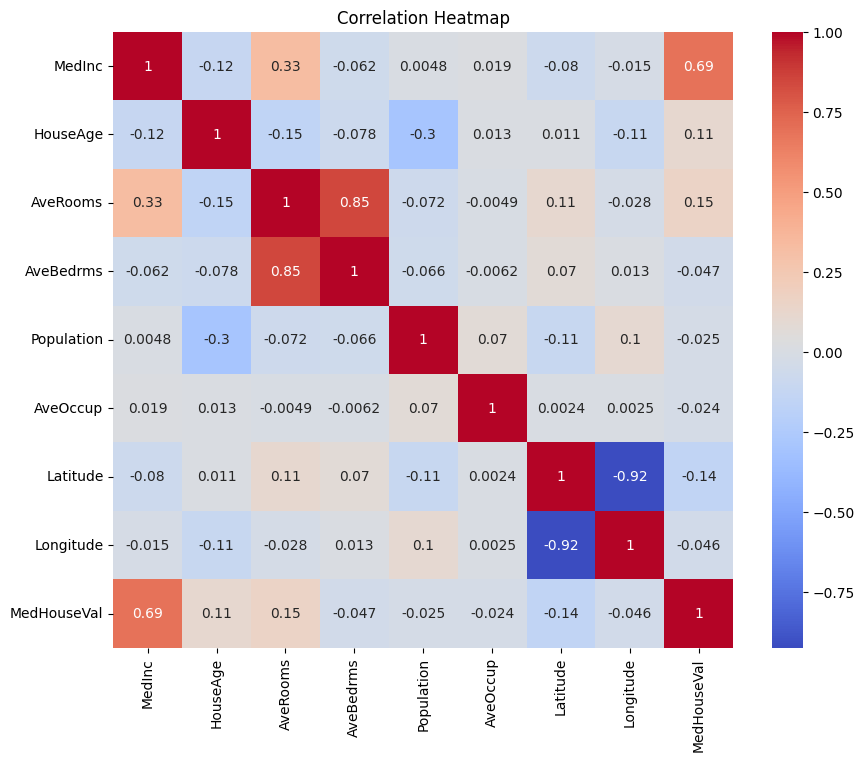

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,
cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

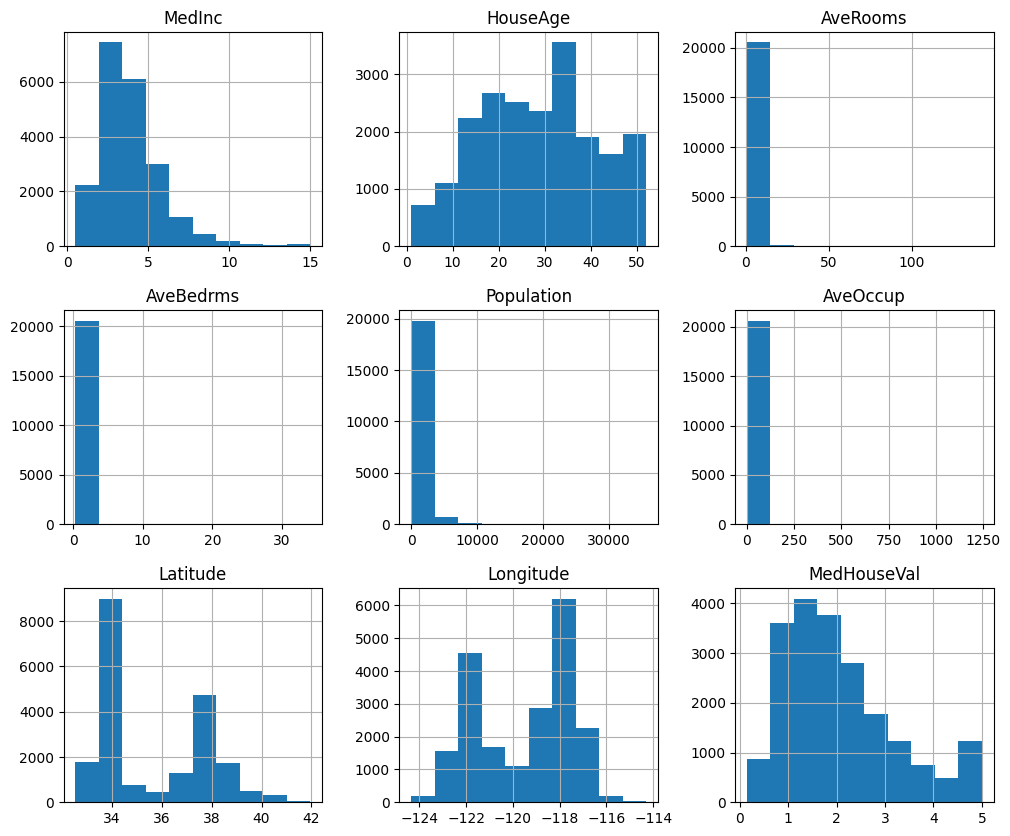

In [6]:
df.hist(figsize=(12,10))
plt.show()

In [7]:
# Features
X = df.drop(columns="MedHouseVal")

# Target
y = df["MedHouseVal"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [9]:
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model Training compeleted.")

Model Training compeleted.


In [10]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [11]:
# MAE
mae = mean_absolute_error(y_test,
y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test,
y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5332001304956557
RMSE: 0.7455813830127758
R2 Score: 0.5757877060324514


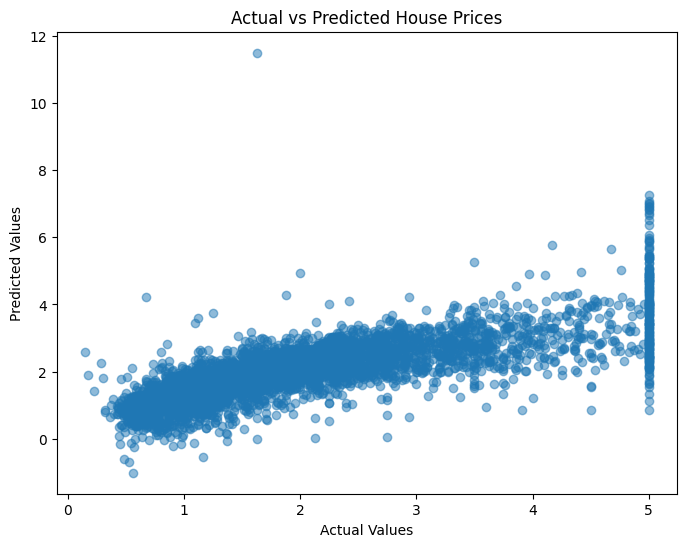

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

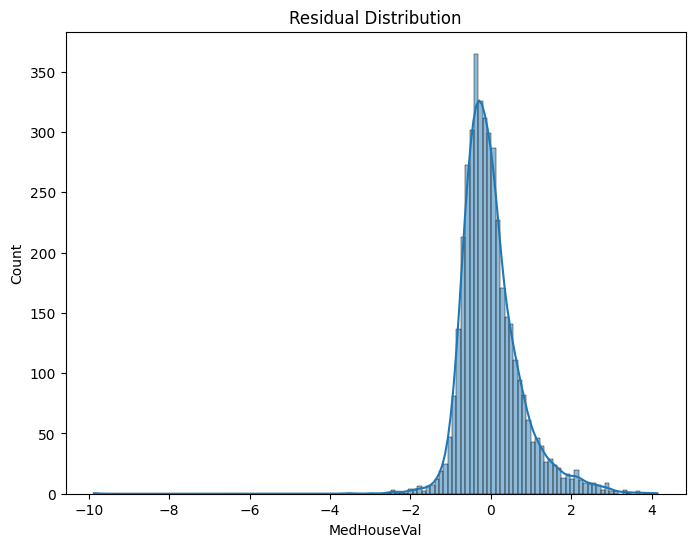

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


In [15]:
import pickle

with open("linear_regression_model.pkl",
"wb") as file:
    pickle.dump(model, file)

print("Model saved sucessfully.")

Model saved sucessfully.
